# Depolarizing Local Noise

- **PEPS ML decoder** (informed: uses local depolarizing rates)
- **MWPM** (informed: builds matching from DEM with local depolarizing rates)
- **Uniform baseline** (both decoders assuming uniform `p = p_mean`)

Noise model: quasistatic local depolarizing, `p_i ~ Normal(p_mean, sigma_frac * p_mean)`.  
Distances: 3, 5, (7).

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math

with open('depolarizing_results.pkl', 'rb') as f:
    data = pickle.load(f)

meta          = data['meta']
results       = data['results']
distances     = meta['distances']
p_mean_values = meta['p_mean_values']
shots         = meta['shots']
sigma_frac    = meta['sigma_frac']

# Adapter dicts: uniform key names so all plot cells work unchanged
peps_results = {d: {
    'local_full_mean': results[d]['local_full_mean'],
    'local_full_std':  results[d]['local_full_std'],
    'local_x_mean':    results[d]['local_x_mean'],
    'local_z_mean':    results[d]['local_z_mean'],
    'uniform_full':    results[d]['uniform_full'],
} for d in distances}

mwpm_results = {d: {
    'local_full_mean': results[d]['mwpm_local_full_mean'],
    'local_full_std':  results[d]['mwpm_local_full_std'],
    'local_x_mean':    results[d]['mwpm_local_x_mean'],
    'local_z_mean':    results[d]['mwpm_local_z_mean'],
    'uniform_full':    results[d]['mwpm_uniform_full'],
} for d in distances}

colors = ['tab:blue', 'tab:orange', 'tab:green']

print('Distances:', distances)
print('p_mean_values:', [float(f'{p:.4g}') for p in p_mean_values])
print(f'shots={shots}  sigma_frac={sigma_frac}')
print('PEPS keys:', list(peps_results[distances[0]].keys()))
print('MWPM keys:', list(mwpm_results[distances[0]].keys()))

Distances: [3, 5, 7]
p_mean_values: [0.01, 0.01395, 0.01946, 0.02714, 0.03786, 0.05282, 0.07368, 0.1028, 0.1434, 0.2]
shots=10000  sigma_frac=0.4
PEPS keys: ['local_full_mean', 'local_full_std', 'local_x_mean', 'local_z_mean', 'uniform_full']
MWPM keys: ['local_full_mean', 'local_full_std', 'local_x_mean', 'local_z_mean', 'uniform_full']


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

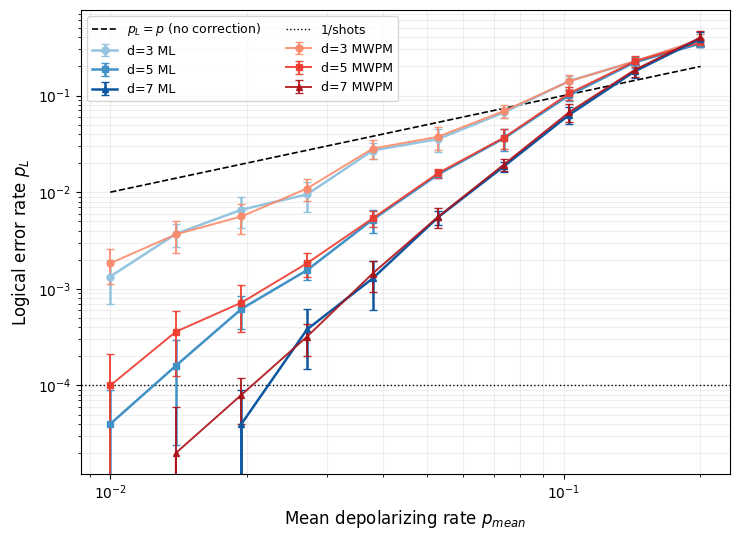

In [2]:
# Plot 1: ML vs MWPM — full logical error rate, local noise
n = len(distances)
blue_colors = [cm.Blues(0.4 + 0.45 * i / (n - 1)) for i in range(n)]
red_colors  = [cm.Reds( 0.4 + 0.45 * i / (n - 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(p_mean_values, p_mean_values, 'k--', linewidth=1.2, label='$p_L = p$ (no correction)')
ax.axhline(y=1/shots, color='k', linestyle=':', linewidth=1.0, label='1/shots')
types = ['o', 's', '^']
for i, d in enumerate(distances):
    pr = peps_results[d]
    mr = mwpm_results[d]
    ax.errorbar(
        p_mean_values, pr['local_full_mean'], yerr=pr['local_full_std'],
        fmt=types[i]+'-', color=blue_colors[i], markersize=5, linewidth=1.8, capsize=3,
        label=f'd={d} ML',
    )
    ax.errorbar(
        p_mean_values, mr['local_full_mean'], yerr=mr['local_full_std'],
        fmt=types[i]+'-', color=red_colors[i], markersize=5, linewidth=1.4, capsize=3, alpha=0.9,
        label=f'd={d} MWPM',
    )

handles, labels = ax.get_legend_handles_labels()
ncol = 2
nrow = math.ceil(len(handles) / ncol)
order = [(k % nrow) * ncol + (k // nrow) for k in range(len(handles))]
ax.legend([handles[i] for i in order], [labels[i] for i in order], fontsize=9, ncol=ncol)

ax.set_xlabel('Mean depolarizing rate $p_{mean}$', fontsize=12)
ax.set_ylabel('Logical error rate $p_L$', fontsize=12)
# ax.axis([0.9*1e-2, 0.21,1e-4, 1])
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.savefig('local_noise_peps_vs_mwpm.png', dpi=160)
plt.show()

# Spin qubit - Z error channel 

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('spin_qubit_results.pkl', 'rb') as f:
    payload = pickle.load(f)

meta    = payload['meta']
results = payload['results']

distances     = meta['distances']
p_mean_values = meta['p_mean_values']
sigma_frac    = meta['sigma_frac']
shots         = meta['shots']
Nkeep         = meta['Nkeep']
num_maps      = meta['num_maps']

print('Loaded results')
print(f'  distances     = {distances}')
print(f'  p_mean_values = {[float(f"{p:.4g}") for p in p_mean_values]}')
print(f'  shots         = {shots}')
print(f'  Nkeep         = {Nkeep}')
print(f'  sigma_frac    = {sigma_frac}')
print(f'  num_maps      = {num_maps}')

Loaded results
  distances     = [3, 5]
  p_mean_values = [0.01, 0.01313, 0.01724, 0.02264, 0.02972, 0.03903, 0.05125, 0.06729, 0.08835, 0.116, 0.1523, 0.2]
  shots         = 10000
  Nkeep         = 32
  sigma_frac    = 0.3
  num_maps      = 3


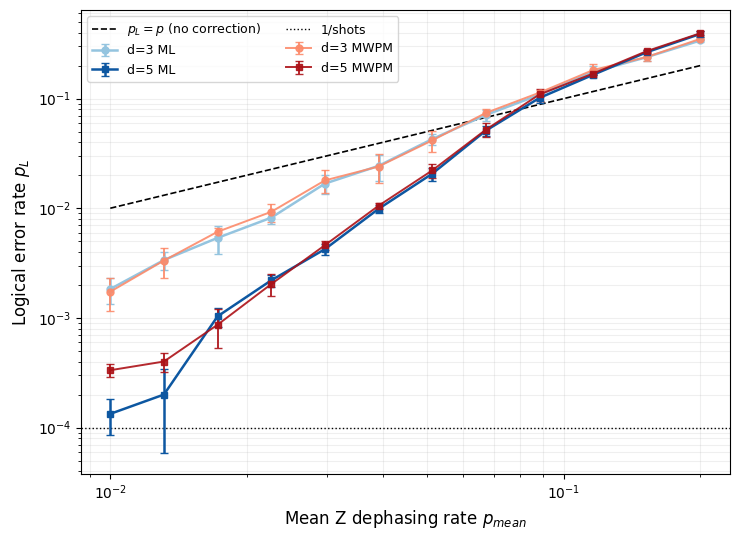

In [4]:
# Plot 1: ML vs MWPM — local Z dephasing
import matplotlib.cm as cm
import math

n = len(distances)
blue_colors = [cm.Blues(0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]
red_colors  = [cm.Reds( 0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(p_mean_values, p_mean_values, 'k--', linewidth=1.2, label='$p_L = p$ (no correction)')
ax.axhline(y=1/shots, color='k', linestyle=':', linewidth=1.0, label='1/shots')

types = ['o', 's', '^']
for i, d in enumerate(distances):
    r = results[d]
    ax.errorbar(
        p_mean_values, r['peps_local_mean'], yerr=r['peps_local_std'],
        fmt=types[i]+'-', color=blue_colors[i], markersize=5, linewidth=1.8, capsize=3,
        label=f'd={d} ML',
    )
    ax.errorbar(
        p_mean_values, r['mwpm_local_mean'], yerr=r['mwpm_local_std'],
        fmt=types[i]+'-', color=red_colors[i], markersize=5, linewidth=1.4, capsize=3, alpha=0.9,
        label=f'd={d} MWPM',
    )

handles, labels = ax.get_legend_handles_labels()
ncol = 2
nrow = math.ceil(len(handles) / ncol)
order = [(k % nrow) * ncol + (k // nrow) for k in range(len(handles))]
ax.legend([handles[i] for i in order], [labels[i] for i in order], fontsize=9, ncol=ncol)

ax.set_xlabel('Mean Z dephasing rate $p_{mean}$', fontsize=12)
ax.set_ylabel('Logical error rate $p_L$', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.savefig('spin_qubit_peps_vs_mwpm_local.png', dpi=160)
plt.show()

# EO qubit - X, Z error channel 

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('eo_qubit_results.pkl', 'rb') as f:
    payload = pickle.load(f)

meta    = payload['meta']
results = payload['results']

distances     = meta['distances']
p_mean_values = meta['p_mean_values']
sigma_frac    = meta['sigma_frac']
shots         = meta['shots']
Nkeep         = meta['Nkeep']
num_maps      = meta['num_maps']

print('Loaded results')
print(f'  distances     = {distances}')
print(f'  p_mean_values = {[float(f"{p:.4g}") for p in p_mean_values]}')
print(f'  shots         = {shots}')
print(f'  Nkeep         = {Nkeep}')
print(f'  sigma_frac    = {sigma_frac}')
print(f'  num_maps      = {num_maps}')
print(f'  axis model    = {meta["axis_model"]}')

Loaded results
  distances     = [3, 5]
  p_mean_values = [0.01, 0.01395, 0.01946, 0.02714, 0.03786, 0.05282, 0.07368, 0.1028, 0.1434, 0.2]
  shots         = 10000
  Nkeep         = 32
  sigma_frac    = 0.3
  num_maps      = 3
  axis model    = p_mean_z = p_mean_n = p_mean


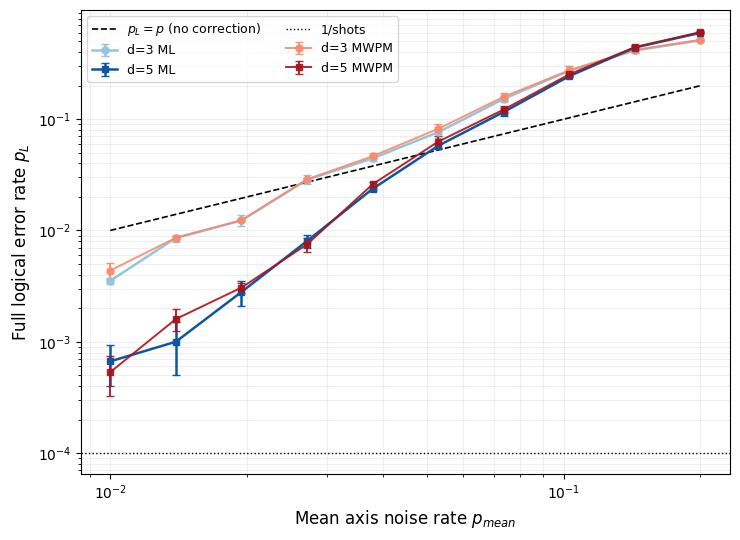

In [6]:
# Plot 1: ML vs MWPM — local EO qubit noise (full logical)
import matplotlib.cm as cm
import math

n = len(distances)
blue_colors = [cm.Blues(0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]
red_colors  = [cm.Reds( 0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(p_mean_values, p_mean_values, 'k--', linewidth=1.2, label='$p_L = p$ (no correction)')
ax.axhline(y=1/shots, color='k', linestyle=':', linewidth=1.0, label='1/shots')

types = ['o', 's', '^']
for i, d in enumerate(distances):
    r = results[d]
    ax.errorbar(
        p_mean_values, r['peps_local_mean'], yerr=r['peps_local_std'],
        fmt=types[i]+'-', color=blue_colors[i], markersize=5, linewidth=1.8, capsize=3,
        label=f'd={d} ML',
    )
    ax.errorbar(
        p_mean_values, r['mwpm_local_mean'], yerr=r['mwpm_local_std'],
        fmt=types[i]+'-', color=red_colors[i], markersize=5, linewidth=1.4, capsize=3, alpha=0.9,
        label=f'd={d} MWPM',
    )

handles, labels = ax.get_legend_handles_labels()
ncol = 2
nrow = math.ceil(len(handles) / ncol)
order = [(k % nrow) * ncol + (k // nrow) for k in range(len(handles))]
ax.legend([handles[i] for i in order], [labels[i] for i in order], fontsize=9, ncol=ncol)

ax.set_xlabel('Mean axis noise rate $p_{mean}$', fontsize=12)
ax.set_ylabel('Full logical error rate $p_L$', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.savefig('eo_qubit_peps_vs_mwpm_local.png', dpi=160)
plt.show()